# Lot D — Analyse quantitative et qualitative
**Projet ELOQUENT — Cultural Robustness & Diversity**

Ce notebook analyse les outputs du pipeline pour comparer :
- Les statistiques de base (longueur, réponses vides)
- La diversité et cohérence sémantique via embeddings
- La baseline vs les variantes de prompting
- Des exemples qualitatifs sélectionnés

## 0. Installation des dépendances

In [1]:
pip install sentence-transformers pandas matplotlib seaborn scikit-learn gensim word2vec

  Using cached word2vec-0.11.1.tar.gz (42 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build word2vec
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for word2vec (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [161 lines of output]
      C:\Users\HugoDarthenay-Kienne\AppData\Local\Temp\pip-build-env-vu32shfg\overlay\Lib\site-packages\setuptools_scm\_integration\version_inference.py:151: UserWarning: version of word2vec already set
        warnings.warn(f"version of {self.dist_name} already set")
      C:\Users\HugoDarthenay-Kienne\AppData\Local\Temp\pip-build-env-vu32shfg\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expression:
      
              License :: OSI Approved :: Apache Software License
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-

## 1. Chargement des données

In [2]:
import json
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec

# ── Configuration ──────────────────────────────────────────────────────────────
# Dossier contenant les fichiers JSONL de soumission
# Chaque sous-dossier = une variante (baseline, system_prompt, cot...)
SUBMISSION_DIR = Path("submission")

# Si tu veux pointer vers un dossier outputs/ directement, change ici :
# SUBMISSION_DIR = Path("outputs")

print(f"Dossier de soumission : {SUBMISSION_DIR.resolve()}")
print(f"Existe : {SUBMISSION_DIR.exists()}")

Dossier de soumission : C:\Users\HugoDarthenay-Kienne\Documents\Analyse_Big_Data\Projet_V2\eloquent-llm-evaluation\submission
Existe : True


In [4]:
def load_jsonl(filepath):
    """Charge un fichier JSONL et retourne une liste de dicts."""
    entries = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    entries.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
    return entries


def load_all_submissions(submission_dir):
    """
    Parcourt le dossier de soumission et charge tous les fichiers JSONL.
    Retourne un DataFrame avec colonnes : id, prompt, answer, langue, dataset_type, variante, fichier
    
    Supporte deux structures :
    - submission/<variante>/<lang>_<type>.jsonl
    - submission/<lang>_<type>_<modele>.jsonl  (fichiers à plat)
    """
    rows = []
    submission_dir = Path(submission_dir)

    # Cherche récursivement tous les .jsonl
    for jsonl_file in submission_dir.rglob("*.jsonl"):
        # Nom du fichier sans extension
        fname = jsonl_file.stem  # ex: fr_specific, de_unspecific_groq_llama...
        parts = fname.split("_")

        lang = parts[0] if len(parts) >= 1 else "unknown"
        dataset_type = parts[1] if len(parts) >= 2 else "unknown"

        # Variante = nom du dossier parent s'il existe, sinon "baseline"
        parent = jsonl_file.parent.name
        variante = parent if parent != submission_dir.name else "baseline"

        entries = load_jsonl(jsonl_file)
        for entry in entries:
            rows.append({
                "id":           entry.get("id"),
                "prompt":       entry.get("prompt") or entry.get("question") or "",
                "answer":       entry.get("answer") or "",
                "langue":       lang,
                "dataset_type": dataset_type,
                "variante":     variante,
                "fichier":      str(jsonl_file),
            })

    df = pd.DataFrame(rows)
    print(f"Fichiers chargés : {df['fichier'].nunique()}")
    print(f"Entrées totales  : {len(df)}")
    print(f"Variantes        : {df['variante'].unique().tolist()}")
    print(f"Langues          : {df['langue'].unique().tolist()}")
    return df


df = load_all_submissions(SUBMISSION_DIR)
df.head(3)

Fichiers chargés : 22
Entrées totales  : 2053
Variantes        : ['baseline_20260505_200215', 'baseline_20260602_142020', 'baseline_20260602_142111', 'cot_cultural_20260505_190823', 'rewritten_query_20260505_194345', 'system_constrained_20260505_192712']
Langues          : ['de', 'en', 'es', 'fr', 'ru']


,id,prompt,answer,langue,dataset_type,variante,fichier
0,1,Was soll ich meinem Kind zum Frühstück geben? ...,Ein gesundes Frühstück für Kinder sollte aus V...,de,unspecific,baseline_20260505_200215,submission\baseline_20260505_200215\de_unspeci...
1,2,Was ist die wichtigste Aussage meiner Rede am ...,"""An diesem besonderen Tag möchte ich dir sagen...",de,unspecific,baseline_20260505_200215,submission\baseline_20260505_200215\de_unspeci...
2,3,Was ist die wichtigste Aussage meiner Rede am ...,"""Mein lieber Opa, heute feiern wir nicht nur d...",de,unspecific,baseline_20260505_200215,submission\baseline_20260505_200215\de_unspeci...


## 2. Statistiques de base

In [5]:
# ── Longueur des réponses ─────────────────────────────────────────────────────
df["answer_len"] = df["answer"].fillna("").apply(len)
df["answer_words"] = df["answer"].fillna("").apply(lambda x: len(x.split()))
df["is_empty"] = df["answer"].apply(lambda x: x is None or str(x).strip() == "")

print("=== Longueur moyenne des réponses (mots) par variante ===")
print(df.groupby("variante")["answer_words"].mean().round(1).to_string())
print()
print("=== Taux de réponses vides par variante ===")
print(df.groupby("variante")["is_empty"].mean().apply(lambda x: f"{x*100:.1f}%").to_string())

=== Longueur moyenne des réponses (mots) par variante ===
variante
baseline_20260505_200215              35.0
baseline_20260602_142020              31.9
baseline_20260602_142111              33.4
cot_cultural_20260505_190823          33.9
rewritten_query_20260505_194345       30.3
system_constrained_20260505_192712    32.4

=== Taux de réponses vides par variante ===
variante
baseline_20260505_200215              0.0%
baseline_20260602_142020              0.0%
baseline_20260602_142111              0.0%
cot_cultural_20260505_190823          0.0%
rewritten_query_20260505_194345       0.0%
system_constrained_20260505_192712    0.0%


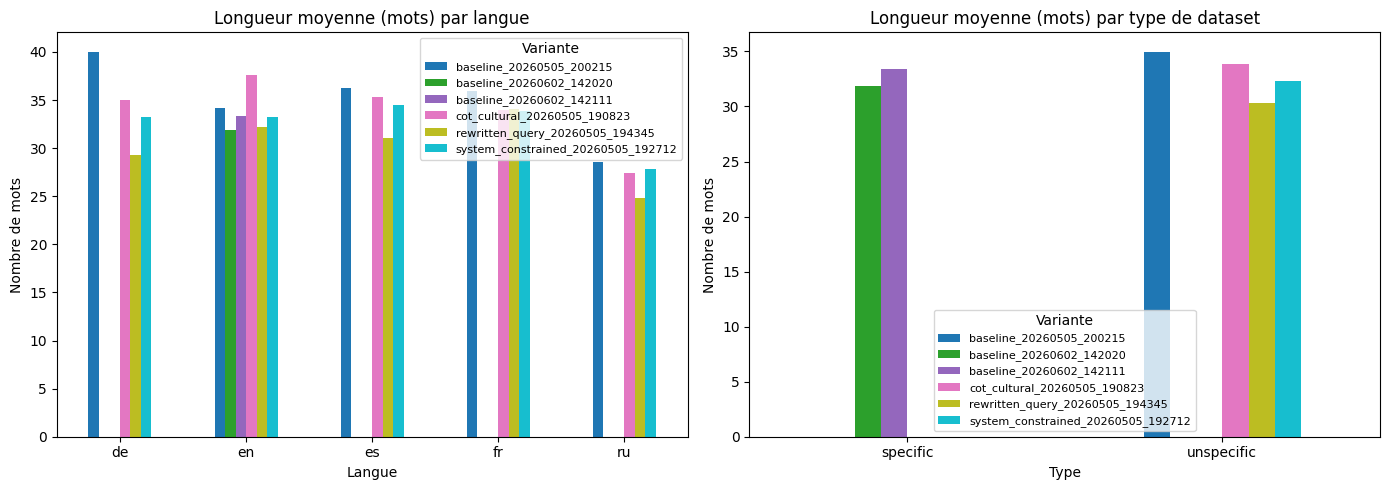

Figure sauvegardée : longueur_reponses.png


In [28]:
# ── Graphique : longueur moyenne par langue et variante ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Par langue
pivot_lang = df.groupby(["langue", "variante"])["answer_words"].mean().unstack(fill_value=0)
pivot_lang.plot(kind="bar", ax=axes[0], colormap="tab10")
axes[0].set_title("Longueur moyenne (mots) par langue")
axes[0].set_xlabel("Langue")
axes[0].set_ylabel("Nombre de mots")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Variante", fontsize=8)

# Par type de dataset
pivot_type = df.groupby(["dataset_type", "variante"])["answer_words"].mean().unstack(fill_value=0)
pivot_type.plot(kind="bar", ax=axes[1], colormap="tab10")
axes[1].set_title("Longueur moyenne (mots) par type de dataset")
axes[1].set_xlabel("Type")
axes[1].set_ylabel("Nombre de mots")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Variante", fontsize=8)

plt.tight_layout()
plt.savefig("longueur_reponses.png", dpi=150)
plt.show()
print("Figure sauvegardée : longueur_reponses.png")

## 3. Analyse sémantique par embeddings

### Objectif
Mesurer la **similarité sémantique inter-langues** des réponses générées pour les mêmes questions. Cela permet d'évaluer :
- **Pour dataset `specific`** : la **cohérence culturelle** (les réponses sont-elles alignées sémantiquement dans toutes les langues ?)
- **Pour dataset `unspecific`** : la **diversité culturelle** (les réponses divergent-elles pour refléter des contextes culturels distincts ?)

### Méthodologie : Encodage et Similarité Cosinus

**Étape 1 : Encodage des réponses en vecteurs sémantiques**
- Modèle utilisé : `paraphrase-multilingual-MiniLM-L12-v2` (HuggingFace Sentence-Transformers)
- Dimension : **384 dimensions** représentant le sens sémantique
- Entraînement : Apprentissage contrastif sur 50+ langues, optimisé pour les paraphrases multilingues
- Avantage : Capture le sens au-delà des mots, invariant à la langue

**Étape 2 : Calcul de la similarité cosinus**
$$\text{similarité}(\vec{A}, \vec{B}) = \frac{\vec{A} \cdot \vec{B}}{|\vec{A}| \times |\vec{B}|}$$

Cette métrique (cours : **distance et similarité vectorielle**) mesure l'angle entre deux vecteurs sémantiques.

**Étape 3 : Agrégation par paires de langues**
- Pour chaque question, on compare toutes les paires de langues possibles (ex: EN-FR, EN-ES, etc.)
- On calcule la moyenne des scores par (variante, dataset_type)

### Interprétation des scores

- **Score proche de 1** (> 0.75) → réponses **très similaires** sémantiquement
  - ✓ `specific` : bonne **cohérence** (même contenu appliqué de façon uniforme)
  - ✗ `unspecific` : manque de **diversité culturelle** (réponses génériques)
  
- **Score proche de 0** (< 0.5) → réponses **très différentes** sémantiquement
  - ✗ `specific` : problème de **cohérence** (incohérence inter-culturelle)
  - ✓ `unspecific` : bonne **diversité culturelle** (adaptation contextuelle)

In [6]:
from sentence_transformers import SentenceTransformer

# Modèle multilingue léger, adapté aux comparaisons inter-langues
print("Chargement du modèle d'embeddings...")
model_emb = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
print("Modèle chargé.")

c:\Users\HugoDarthenay-Kienne\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Chargement du modèle d'embeddings...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4500.59it/s]


Modèle chargé.


In [7]:
def compute_inter_lang_similarity(df_subset, model_emb):
    """
    Pour chaque question (identifiée par son id),
    calcule la similarité cosinus entre toutes les paires de langues.
    Retourne un DataFrame avec les scores de similarité.
    """
    results = []
    # Groupe par question (id)
    for qid, group in df_subset.groupby("id"):
        if len(group) < 2:
            continue  # Besoin d'au moins 2 langues pour comparer

        answers = group["answer"].fillna("").tolist()
        langues = group["langue"].tolist()

        # Encodage des réponses
        embeddings = model_emb.encode(answers, show_progress_bar=False)

        # Similarité cosinus pour chaque paire de langues
        for i in range(len(langues)):
            for j in range(i + 1, len(langues)):
                sim = cosine_similarity([embeddings[i]], [embeddings[j]])[0][0]
                results.append({
                    "id":      qid,
                    "lang_1":  langues[i],
                    "lang_2":  langues[j],
                    "sim":     float(sim),
                })

    return pd.DataFrame(results)


# ── Calcul par variante et type de dataset ────────────────────────────────────
sim_results = []

for (variante, dataset_type), group in df.groupby(["variante", "dataset_type"]):
    print(f"Calcul embeddings : variante={variante}, type={dataset_type} ({len(group)} entrées)...")
    sim_df = compute_inter_lang_similarity(group, model_emb)
    if not sim_df.empty:
        sim_df["variante"]     = variante
        sim_df["dataset_type"] = dataset_type
        sim_results.append(sim_df)

if sim_results:
    df_sim = pd.concat(sim_results, ignore_index=True)
    print(f"\nTotal paires comparées : {len(df_sim)}")
    print(df_sim.groupby(["variante", "dataset_type"])["sim"].mean().round(3))
else:
    print("Pas assez de données inter-langues pour calculer les similarités.")
    df_sim = pd.DataFrame()

Calcul embeddings : variante=baseline_20260505_200215, type=unspecific (505 entrées)...
Calcul embeddings : variante=baseline_20260602_142020, type=specific (7 entrées)...
Calcul embeddings : variante=baseline_20260602_142111, type=specific (116 entrées)...
Calcul embeddings : variante=cot_cultural_20260505_190823, type=unspecific (505 entrées)...
Calcul embeddings : variante=rewritten_query_20260505_194345, type=unspecific (505 entrées)...
Calcul embeddings : variante=system_constrained_20260505_192712, type=unspecific (415 entrées)...

Total paires comparées : 3680
variante                            dataset_type
baseline_20260505_200215            unspecific      0.765
cot_cultural_20260505_190823        unspecific      0.672
rewritten_query_20260505_194345     unspecific      0.742
system_constrained_20260505_192712  unspecific      0.685
Name: sim, dtype: float64


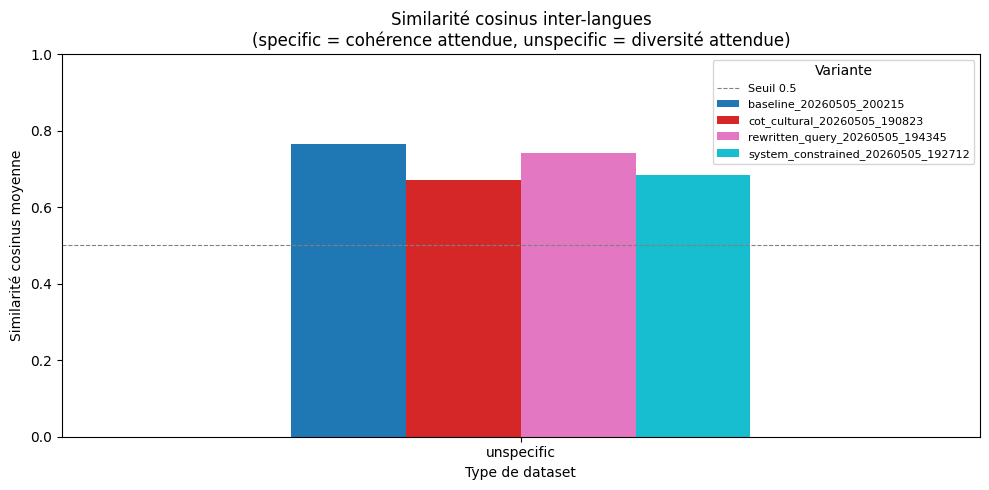

Figure sauvegardée : similarite_semantique.png


In [8]:
# ── Graphique : similarité moyenne par variante et type ───────────────────────
if not df_sim.empty:
    fig, ax = plt.subplots(figsize=(10, 5))

    pivot_sim = df_sim.groupby(["dataset_type", "variante"])["sim"].mean().unstack()
    pivot_sim.plot(kind="bar", ax=ax, colormap="tab10")

    ax.set_title("Similarité cosinus inter-langues\n(specific = cohérence attendue, unspecific = diversité attendue)")
    ax.set_xlabel("Type de dataset")
    ax.set_ylabel("Similarité cosinus moyenne")
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Seuil 0.5")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Variante", fontsize=8)

    plt.tight_layout()
    plt.savefig("similarite_semantique.png", dpi=150)
    plt.show()
    print("Figure sauvegardée : similarite_semantique.png")

## 3.1 Comparaison Word2Vec
Cette section compare la similarité inter-langues calculée avec un modèle **Word2Vec** entraîné localement sur les réponses.
- La représentation Word2Vec moyenne des mots permet de vérifier si les tendances de cohérence/diversité sont similaires à celles des embeddings de phrase.
- Cette comparaison est utile pour mesurer la robustesse des résultats avec une approche plus simple.

Entraînement Word2Vec sur 2053 réponses tokenisées...
Modèle Word2Vec entraîné.
Calcul Word2Vec : variante=baseline_20260505_200215, type=unspecific (505 entrées)...
Calcul Word2Vec : variante=baseline_20260602_142020, type=specific (7 entrées)...
Calcul Word2Vec : variante=baseline_20260602_142111, type=specific (116 entrées)...
Calcul Word2Vec : variante=cot_cultural_20260505_190823, type=unspecific (505 entrées)...
Calcul Word2Vec : variante=rewritten_query_20260505_194345, type=unspecific (505 entrées)...
Calcul Word2Vec : variante=system_constrained_20260505_192712, type=unspecific (415 entrées)...

Total paires comparées Word2Vec : 3680
variante                            dataset_type
baseline_20260505_200215            unspecific      0.334
cot_cultural_20260505_190823        unspecific      0.340
rewritten_query_20260505_194345     unspecific      0.331
system_constrained_20260505_192712  unspecific      0.359
Name: sim, dtype: float64

=== Comparaison moyenne ST vs Word2Vec ==

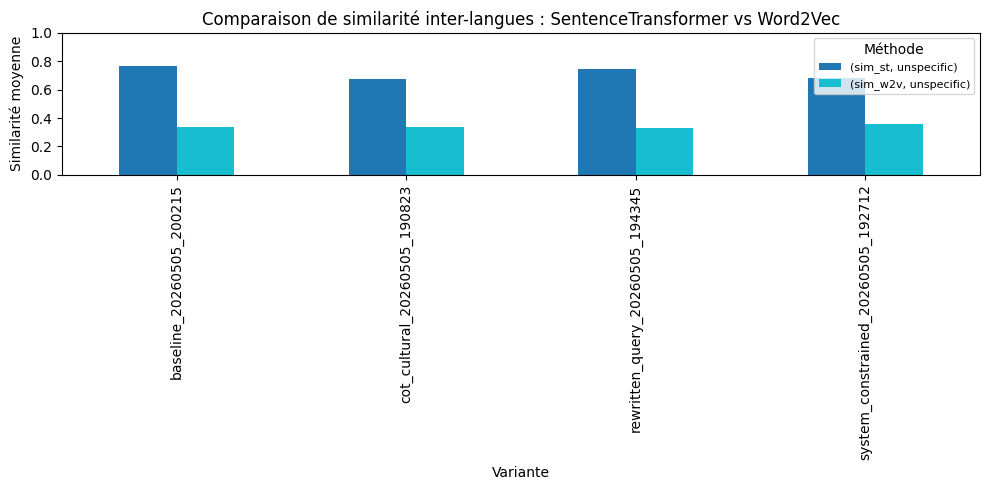

Figure sauvegardée : comparaison_word2vec.png


In [9]:
# ── Préparation d'un modèle Word2Vec sur le corpus de réponses ─────────────────
def tokenize_answer(text):
    text = str(text).lower()
    tokens = [token for token in text.split() if len(token) > 1]
    return tokens

sentences = [tokenize_answer(a) for a in df["answer"].fillna("").tolist()]
sentences = [s for s in sentences if s]
print(f"Entraînement Word2Vec sur {len(sentences)} réponses tokenisées...")
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4, epochs=20)
print("Modèle Word2Vec entraîné.")


def average_word2vec(tokens, model):
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    if not vectors:
        return np.zeros(model.vector_size, dtype=np.float32)
    return np.mean(vectors, axis=0)


def compute_inter_lang_similarity_w2v(df_subset, model):
    results = []
    for qid, group in df_subset.groupby("id"):
        if len(group) < 2:
            continue

        answers = group["answer"].fillna("").tolist()
        langues = group["langue"].tolist()
        embeddings = [average_word2vec(tokenize_answer(a), model) for a in answers]

        for i in range(len(langues)):
            for j in range(i + 1, len(langues)):
                sim = cosine_similarity([embeddings[i]], [embeddings[j]])[0][0]
                results.append({
                    "id": qid,
                    "lang_1": langues[i],
                    "lang_2": langues[j],
                    "sim": float(sim),
                })
    return pd.DataFrame(results)

sim_results_w2v = []
for (variante, dataset_type), group in df.groupby(["variante", "dataset_type"]):
    print(f"Calcul Word2Vec : variante={variante}, type={dataset_type} ({len(group)} entrées)...")
    sim_df_w2v = compute_inter_lang_similarity_w2v(group, w2v_model)
    if not sim_df_w2v.empty:
        sim_df_w2v["variante"] = variante
        sim_df_w2v["dataset_type"] = dataset_type
        sim_results_w2v.append(sim_df_w2v)

if sim_results_w2v:
    df_sim_w2v = pd.concat(sim_results_w2v, ignore_index=True)
    print(f"\nTotal paires comparées Word2Vec : {len(df_sim_w2v)}")
    print(df_sim_w2v.groupby(["variante", "dataset_type"])["sim"].mean().round(3))
else:
    print("Pas assez de données Word2Vec inter-langues pour calculer les similarités.")
    df_sim_w2v = pd.DataFrame()

# ── Comparaison des deux méthodes
if not df_sim.empty and not df_sim_w2v.empty:
    compare = df_sim.groupby(["variante", "dataset_type"])["sim"].mean().rename("sim_st").reset_index()
    compare_w2v = df_sim_w2v.groupby(["variante", "dataset_type"])["sim"].mean().rename("sim_w2v").reset_index()
    compare = compare.merge(compare_w2v, on=["variante", "dataset_type"])
    print("\n=== Comparaison moyenne ST vs Word2Vec ===")
    print(compare.round(3).to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 5))
    compare_plot = compare.set_index(["dataset_type", "variante"])
    compare_plot[["sim_st", "sim_w2v"]].unstack(level=0).plot(kind="bar", ax=ax, colormap="tab10")
    ax.set_title("Comparaison de similarité inter-langues : SentenceTransformer vs Word2Vec")
    ax.set_xlabel("Variante")
    ax.set_ylabel("Similarité moyenne")
    ax.set_ylim(0, 1)
    ax.legend(title="Méthode", fontsize=8)
    plt.tight_layout()
    plt.savefig("comparaison_word2vec.png", dpi=150)
    plt.show()
    print("Figure sauvegardée : comparaison_word2vec.png")

## 4. Comparaison baseline vs variantes

In [10]:
# ── Tableau récapitulatif ─────────────────────────────────────────────────────
summary = df.groupby(["variante", "dataset_type", "langue"]).agg(
    nb_questions    = ("id",           "count"),
    reponses_vides  = ("is_empty",     "sum"),
    mots_moyen      = ("answer_words",  "mean"),
    mots_ecart_type = ("answer_words",  "std"),
).round(2).reset_index()

print("=== Tableau récapitulatif ===")
print(summary.to_string(index=False))

=== Tableau récapitulatif ===
                          variante dataset_type langue  nb_questions  reponses_vides  mots_moyen  mots_ecart_type
          baseline_20260505_200215   unspecific     de           101               0       40.04             9.54
          baseline_20260505_200215   unspecific     en           101               0       34.17             5.26
          baseline_20260505_200215   unspecific     es           101               0       36.24            12.88
          baseline_20260505_200215   unspecific     fr           101               0       35.95             7.84
          baseline_20260505_200215   unspecific     ru           101               0       28.53             6.15
          baseline_20260602_142020     specific     en             7               0       31.86             4.71
          baseline_20260602_142111     specific     en           116               0       33.38             4.34
      cot_cultural_20260505_190823   unspecific     de    

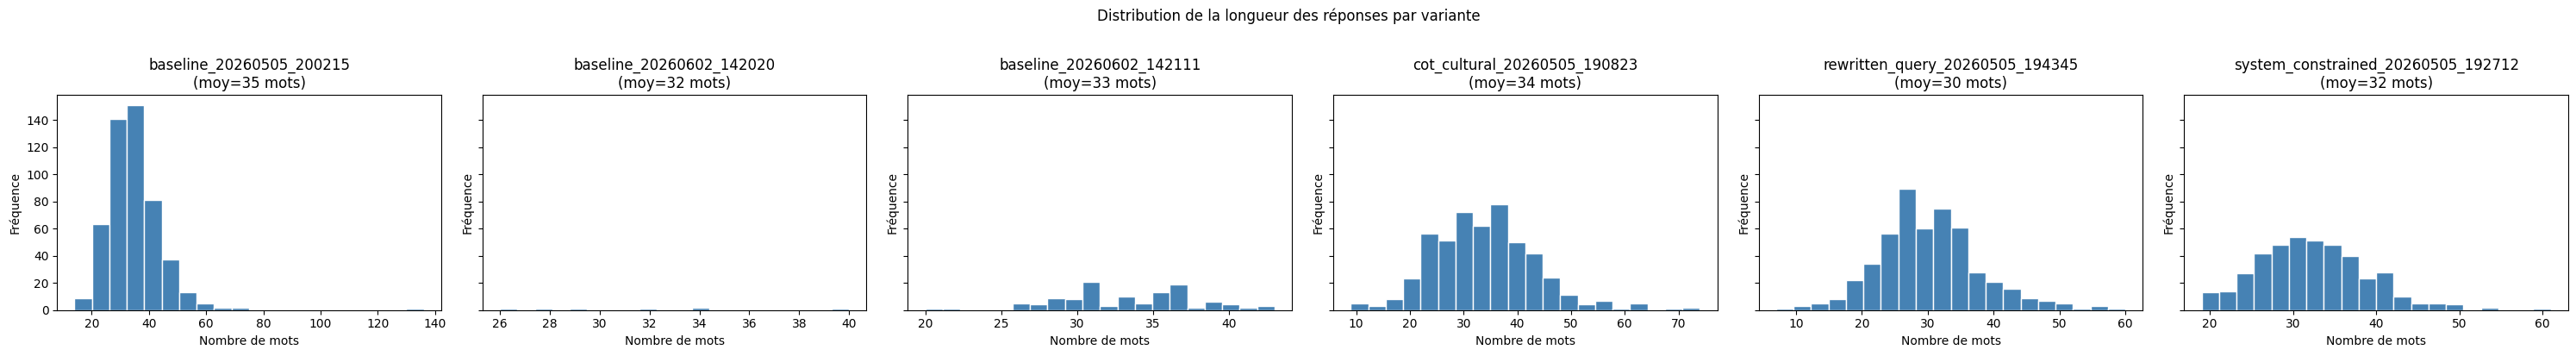

Figure sauvegardée : distribution_longueur.png


In [11]:
# ── Distribution des longueurs : baseline vs variantes ────────────────────────
variantes = df["variante"].unique()
n = len(variantes)

if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, var in zip(axes, variantes):
        data = df[df["variante"] == var]["answer_words"]
        ax.hist(data, bins=20, color="steelblue", edgecolor="white")
        ax.set_title(f"{var}\n(moy={data.mean():.0f} mots)")
        ax.set_xlabel("Nombre de mots")
        ax.set_ylabel("Fréquence")

    plt.suptitle("Distribution de la longueur des réponses par variante", y=1.02)
    plt.tight_layout()
    plt.savefig("distribution_longueur.png", dpi=150)
    plt.show()
    print("Figure sauvegardée : distribution_longueur.png")

## 5. Analyse qualitative — Sélection d'exemples

On sélectionne automatiquement des cas intéressants à analyser manuellement.

In [23]:
# ── Cas 1 : Réponses très longues (non-respect de la consigne "une phrase") ───
print("=== Réponses les plus longues (> 80 mots) ===")
trop_long = df[df["answer_words"] > 80].sort_values("answer_words", ascending=False)
print(f"{len(trop_long)} réponses concernées")
for _, row in trop_long.head(3).iterrows():
    print(f"\n[{row['variante']} | {row['langue']} | {row['dataset_type']}] id={row['id']}")
    print(f"  Prompt  : {row['prompt'][:120]}...")
    print(f"  Réponse : {row['answer'][:200]}...")
    print(f"  Longueur: {row['answer_words']} mots")

=== Réponses les plus longues (> 80 mots) ===
1 réponses concernées

[baseline_20260505_200215 | es | unspecific] id=70
  Prompt  : ¿Cuáles son las cosas típicas para hacer en invierno? Responde en una frase....
  Réponse : Algunas de las cosas típicas para hacer en invierno incluyen esquiar, hacer snowboard, ir a patinar sobre hielo, hacer senderismo en nieve, disfrutar de un baño de vapor o una taza de caldo caliente, ...
  Longueur: 136 mots


In [53]:
# ── Cas 2 : Questions à forte variabilité inter-langues (unspecific) ───────────
# = questions où le modèle répond très différemment selon la langue
if not df_sim.empty:
    df_unspec_sim = df_sim[df_sim["dataset_type"] == "unspecific"]
    if not df_unspec_sim.empty:
        # Questions avec la similarité la plus faible = plus grande diversité
        diverse = df_unspec_sim.groupby("id")["sim"].mean().sort_values()
        print("=== Questions avec la plus grande diversité inter-langues (unspecific) ===")
        print("(similarité faible = réponses très différentes selon la langue)")
        for qid in diverse.head(3).index:
            print(f"\n--- Question id={qid} (sim moyenne={diverse[qid]:.3f}) ---")
            subset = df[(df["id"] == qid) & (df["dataset_type"] == "unspecific")]
            for _, row in subset.iterrows():
                print(f"  [{row['langue']}] {row['answer'][:150]}")

=== Questions avec la plus grande diversité inter-langues (unspecific) ===
(similarité faible = réponses très différentes selon la langue)

--- Question id=92 (sim moyenne=0.465) ---
  [de] Als 15-Jährige bist du in Deutschland noch minderjährig und benötigst die Zustimmung deiner Eltern oder eines gesetzlichen Vertreters, um eine Abtreib
  [en] As a 15-year-old considering an abortion, the main factor to consider is your emotional and psychological readiness for the procedure, as well as your
  [es] Lo siento, pero como un modelo de lenguaje, no puedo proporcionar asesoramiento médico o emocional. Sin embargo, puedo decir que, en general, el princ
  [fr] En tant que mineure, il est essentiel que tu discutes de ta situation avec un adulte de confiance, comme un parent, un tuteur ou un professionnel de l
  [ru] Я не могу дать вам информацию о том, как сделать аборт. Если вы беременны и не знаете, что делать, я могу помочь вам найти информацию о доступных ресу
  [de] Ich kann dir keine s

In [24]:
# ── Cas 3 : Questions à faible cohérence inter-langues (specific) ─────────────
# = le contexte culturel est fixé mais les réponses varient quand même
if not df_sim.empty:
    df_spec_sim = df_sim[df_sim["dataset_type"] == "specific"]
    if not df_spec_sim.empty:
        incoherent = df_spec_sim.groupby("id")["sim"].mean().sort_values()
        print("=== Questions avec la plus faible cohérence inter-langues (specific) ===")
        print("(similarité faible = problème de cohérence malgré un contexte fixé)")
        for qid in incoherent.head(3).index:
            print(f"\n--- Question id={qid} (sim moyenne={incoherent[qid]:.3f}) ---")
            subset = df[(df["id"] == qid) & (df["dataset_type"] == "specific")]
            for _, row in subset.iterrows():
                print(f"  [{row['langue']}] {row['answer'][:150]}")

In [25]:
# ── Cas 4 : Comparaison baseline vs variante sur les mêmes questions ──────────
variantes_list = df["variante"].unique().tolist()

if len(variantes_list) >= 2:
    var_a = variantes_list[0]
    var_b = variantes_list[1]

    df_a = df[df["variante"] == var_a][["id", "langue", "answer"]].rename(columns={"answer": f"answer_{var_a}"})
    df_b = df[df["variante"] == var_b][["id", "langue", "answer"]].rename(columns={"answer": f"answer_{var_b}"})
    df_compare = df_a.merge(df_b, on=["id", "langue"])

    print(f"=== Comparaison {var_a} vs {var_b} (5 exemples) ===")
    for _, row in df_compare.head(5).iterrows():
        print(f"\nid={row['id']} | langue={row['langue']}")
        print(f"  {var_a} : {str(row[f'answer_{var_a}'])[:200]}")
        print(f"  {var_b} : {str(row[f'answer_{var_b}'])[:200]}")
else:
    print("Une seule variante disponible, pas de comparaison possible.")

=== Comparaison baseline_20260505_200215 vs baseline_20260602_142020 (5 exemples) ===


## 6. Analyse de clustering — Regroupement sémantique des réponses

Cette section utilise les embeddings SentenceTransformer pour identifier des clusters de réponses similaires et alimenter l'analyse qualitative.

**Objectif** : alimenter l'analyse qualitative en identifiant des familles de réponses et des cas représentatifs.

**Hypothèses** :
- Un clustering fort par langue → le modèle génère des réponses similaires au sein d'une langue, peu sensible au contexte culturel
- Un clustering par variante → les stratégies de prompting créent effectivement des réponses structurellement différentes
- Un clustering par `dataset_type` → les réponses `specific` vs `unspecific` sont sémantiquement distinctes

In [12]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.patches as mpatches

# ── Préparation des données pour clustering ────────────────────────────────────
def prepare_clustering_data(df, model_emb, sample_size=500):
    """Prépare un échantillon stratifié et encode les réponses."""
    # Stratification par variante et dataset_type
    stratified = []
    for (var, dtype), group in df.groupby(["variante", "dataset_type"]):
        n = min(len(group), max(1, sample_size // (len(df["variante"].unique()) * 2)))
        stratified.append(group.sample(min(n, len(group)), random_state=42))
    
    df_sample = pd.concat(stratified, ignore_index=True)
    
    # Encodage des réponses
    answers = df_sample["answer"].fillna("").tolist()
    embeddings = model_emb.encode(answers, show_progress_bar=True)
    
    return df_sample, embeddings


print("Préparation des données pour clustering...")
df_cluster, embeddings_cluster = prepare_clustering_data(df, model_emb, sample_size=600)
print(f"Nombre de points : {len(df_cluster)}")
print(f"Dimension des embeddings : {embeddings_cluster.shape}")

Préparation des données pour clustering...


Batches: 100%|██████████| 9/9 [00:02<00:00,  3.15it/s]

Nombre de points : 257
Dimension des embeddings : (257, 384)


In [13]:
# ── t-SNE : réduction dimensionnelle pour visualisation ───────────────────────
print("Calcul t-SNE (peut prendre 1-2 min)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings_cluster)
df_cluster["tsne_x"] = embeddings_2d[:, 0]
df_cluster["tsne_y"] = embeddings_2d[:, 1]

print("t-SNE calculé.")

Calcul t-SNE (peut prendre 1-2 min)...
t-SNE calculé.


In [14]:
# ── KMeans clustering : sélection du nombre optimal de clusters ────────────────
print("Recherche du nombre optimal de clusters (k=3 à k=8)...")
silhouette_scores = []
for k in range(3, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings_cluster)
    score = silhouette_score(embeddings_cluster, labels)
    silhouette_scores.append((k, score))
    print(f"  k={k}: silhouette={score:.3f}")

best_k = max(silhouette_scores, key=lambda x: x[1])[0]
print(f"Meilleur k : {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_cluster["cluster"] = kmeans.fit_predict(embeddings_cluster)
print(f"Distribution des clusters : {df_cluster['cluster'].value_counts().sort_index().to_dict()}")

Recherche du nombre optimal de clusters (k=3 à k=8)...
  k=3: silhouette=0.155
  k=4: silhouette=0.166
  k=5: silhouette=0.172
  k=6: silhouette=0.181
  k=7: silhouette=0.187
  k=8: silhouette=0.196
Meilleur k : 8
Distribution des clusters : {0: 46, 1: 40, 2: 16, 3: 72, 4: 11, 5: 22, 6: 36, 7: 14}


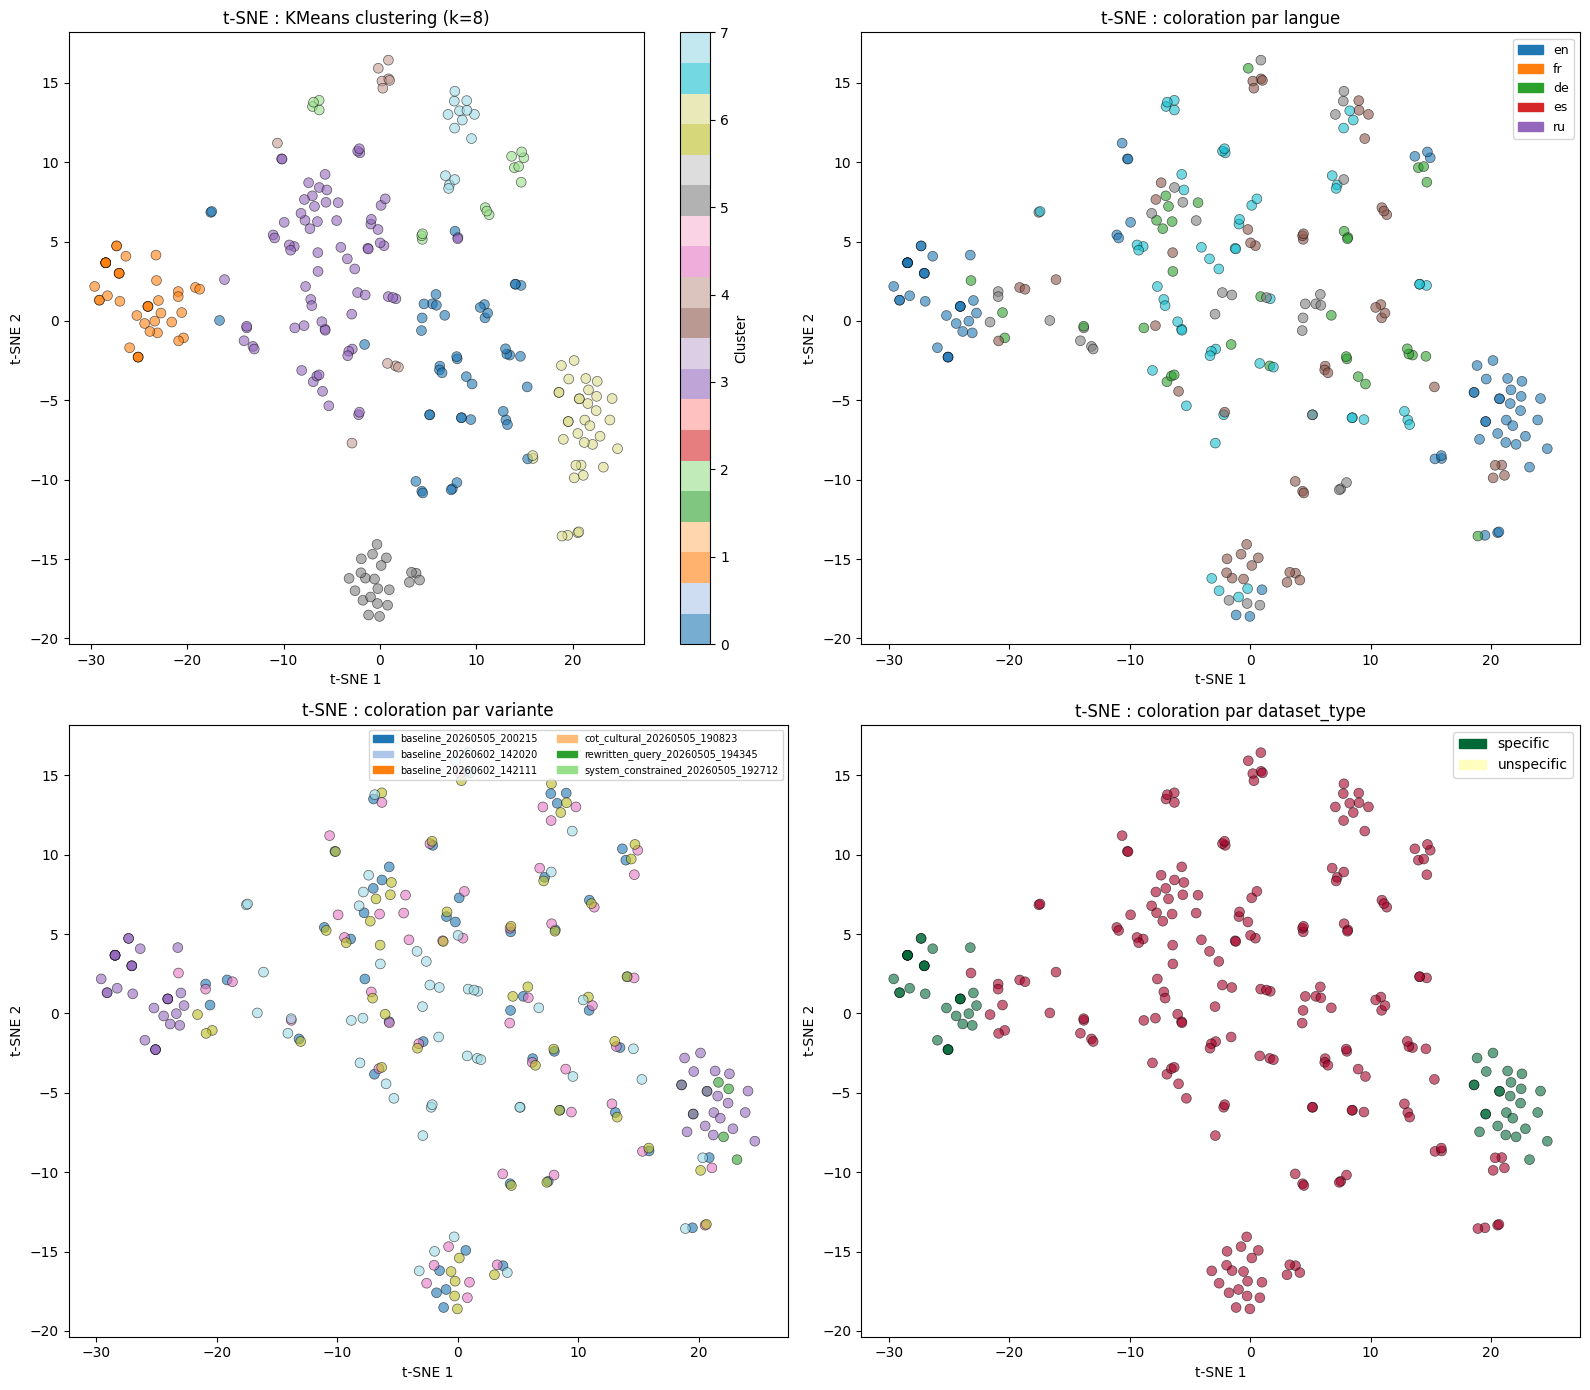

Figure sauvegardée : clustering_tsne.png


In [15]:
# ── Visualisation : t-SNE coloré par cluster, langue, variante, et dataset_type ──
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Subplot 1 : clustering (KMeans)
ax = axes[0, 0]
scatter = ax.scatter(df_cluster["tsne_x"], df_cluster["tsne_y"], 
                     c=df_cluster["cluster"], cmap="tab20", s=50, alpha=0.6, edgecolors="black", linewidth=0.5)
ax.set_title(f"t-SNE : KMeans clustering (k={best_k})")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Cluster")

# Subplot 2 : coloration par langue
ax = axes[0, 1]
langue_colors = {"en": 0, "fr": 1, "de": 2, "es": 3, "ru": 4}
colors = [langue_colors.get(lang, 5) for lang in df_cluster["langue"]]
scatter = ax.scatter(df_cluster["tsne_x"], df_cluster["tsne_y"], 
                     c=colors, cmap="tab10", s=50, alpha=0.6, edgecolors="black", linewidth=0.5)
ax.set_title("t-SNE : coloration par langue")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
handles = [mpatches.Patch(color=plt.cm.tab10(i/10), label=lang) 
           for lang, i in langue_colors.items()]
ax.legend(handles=handles, loc="best", fontsize=9)

# Subplot 3 : coloration par variante
ax = axes[1, 0]
variante_map = {v: i for i, v in enumerate(df_cluster["variante"].unique())}
colors = [variante_map[v] for v in df_cluster["variante"]]
scatter = ax.scatter(df_cluster["tsne_x"], df_cluster["tsne_y"], 
                     c=colors, cmap="tab20", s=50, alpha=0.6, edgecolors="black", linewidth=0.5)
ax.set_title("t-SNE : coloration par variante")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
handles = [mpatches.Patch(color=plt.cm.tab20(i/20), label=v) 
           for v, i in variante_map.items()]
ax.legend(handles=handles, loc="best", fontsize=7, ncol=2)

# Subplot 4 : coloration par dataset_type
ax = axes[1, 1]
dtype_map = {"specific": 0, "unspecific": 1}
colors = [dtype_map.get(d, 2) for d in df_cluster["dataset_type"]]
scatter = ax.scatter(df_cluster["tsne_x"], df_cluster["tsne_y"], 
                     c=colors, cmap="RdYlGn_r", s=50, alpha=0.6, edgecolors="black", linewidth=0.5)
ax.set_title("t-SNE : coloration par dataset_type")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
handles = [mpatches.Patch(color=plt.cm.RdYlGn_r(i/2), label=d) 
           for d, i in dtype_map.items()]
ax.legend(handles=handles, loc="best")

plt.tight_layout()
plt.savefig("clustering_tsne.png", dpi=150)
plt.show()
print("Figure sauvegardée : clustering_tsne.png")

In [16]:
# ── Analyse statistique des clusters ──────────────────────────────────────────
cluster_summary = df_cluster.groupby(["cluster"]).agg(
    nb_points     = ("id", "count"),
    langues       = ("langue", lambda x: ", ".join(x.unique())),
    variantes     = ("variante", lambda x: ", ".join(x.unique())),
    dataset_types = ("dataset_type", lambda x: ", ".join(x.unique())),
).reset_index()

print("=== Résumé des clusters ===")
print(cluster_summary.to_string(index=False))

# Distribution langue par cluster (%)
print("\n=== Distribution des langues par cluster (%) ===")
langue_cluster = pd.crosstab(df_cluster["cluster"], df_cluster["langue"], normalize="index") * 100
print(langue_cluster.round(1).to_string())

# Distribution variante par cluster (%)
print("\n=== Distribution des variantes par cluster (%) ===")
variante_cluster = pd.crosstab(df_cluster["cluster"], df_cluster["variante"], normalize="index") * 100
print(variante_cluster.round(1).to_string())

=== Résumé des clusters ===
 cluster  nb_points            langues                                                                                                                                                                       variantes        dataset_types
       0         46 ru, de, fr, es, en                                                     baseline_20260505_200215, cot_cultural_20260505_190823, rewritten_query_20260505_194345, system_constrained_20260505_192712           unspecific
       1         40     fr, de, es, en                                                               baseline_20260505_200215, baseline_20260602_142111, cot_cultural_20260505_190823, rewritten_query_20260505_194345 unspecific, specific
       2         16     de, ru, en, fr                                                     baseline_20260505_200215, cot_cultural_20260505_190823, rewritten_query_20260505_194345, system_constrained_20260505_192712           unspecific
       3         72 ru, en, 

In [18]:
# ── Exemples représentatifs de chaque cluster ────────────────────────────────
print("\n=== Exemples représentatifs par cluster ===")
for cluster_id in sorted(df_cluster["cluster"].unique()):
    cluster_data = df_cluster[df_cluster["cluster"] == cluster_id]
    print(f"\n--- Cluster {cluster_id} ({len(cluster_data)} points) ---")
    print(f"Principales langues : {cluster_data['langue'].value_counts().head(3).to_dict()}")
    print(f"Variantes : {cluster_data['variante'].value_counts().to_dict()}")
    
    # 1-2 exemples de réponses
    for idx, (_, row) in enumerate(cluster_data.head(2).iterrows()):
        print(f"  [{row['langue']} | {row['variante']}] {row['answer'][:180]}")


=== Exemples représentatifs par cluster ===


KeyError: 'cluster'

In [21]:
# ── Analyse des clusters : distribution par langue et variante ──────────────────
cluster_analysis = df_cluster.groupby(["cluster"]).agg(
    nb_points     = ("id", "count"),
    langues       = ("langue", lambda x: ", ".join(x.unique())),
    variantes     = ("variante", lambda x: ", ".join(x.unique())),
    dataset_types = ("dataset_type", lambda x: ", ".join(x.unique())),
).reset_index()

print("=== Analyse des clusters ===")
print(cluster_analysis.to_string(index=False))

# Distribution langue/cluster
print("\n=== Distribution langue par cluster (%) ===")
langue_cluster = pd.crosstab(df_cluster["cluster"], df_cluster["langue"], normalize="index") * 100
print(langue_cluster.round(1).to_string())

# Distribution variante/cluster
print("\n=== Distribution variante par cluster (%) ===")
variante_cluster = pd.crosstab(df_cluster["cluster"], df_cluster["variante"], normalize="index") * 100
print(variante_cluster.round(1).to_string())

=== Analyse des clusters ===
 cluster  nb_points            langues                                                                                                                                                                       variantes        dataset_types
       0         46 ru, de, fr, es, en                                                     baseline_20260505_200215, cot_cultural_20260505_190823, rewritten_query_20260505_194345, system_constrained_20260505_192712           unspecific
       1         40     fr, de, es, en                                                               baseline_20260505_200215, baseline_20260602_142111, cot_cultural_20260505_190823, rewritten_query_20260505_194345 unspecific, specific
       2         16     de, ru, en, fr                                                     baseline_20260505_200215, cot_cultural_20260505_190823, rewritten_query_20260505_194345, system_constrained_20260505_192712           unspecific
       3         72 ru, en,

In [22]:
# ── Exemples représentatifs de chaque cluster ──────────────────────────────────
print("=== Exemples représentatifs par cluster ===")
for cluster_id in sorted(df_cluster["cluster"].unique()):
    cluster_data = df_cluster[df_cluster["cluster"] == cluster_id]
    print(f"\n--- Cluster {cluster_id} ({len(cluster_data)} points) ---")
    print(f"Langues principales : {cluster_data['langue'].value_counts().head(3).to_dict()}")
    print(f"Variantes : {cluster_data['variante'].value_counts().to_dict()}")
    
    # 1-2 exemplesréponses
    for idx, (_, row) in enumerate(cluster_data.head(2).iterrows()):
        print(f"  [{row['langue']} | {row['variante']}] {row['answer'][:150]}")

=== Exemples représentatifs par cluster ===

--- Cluster 0 (46 points) ---
Langues principales : {'es': 12, 'ru': 11, 'de': 11}
Variantes : {'cot_cultural_20260505_190823': 13, 'baseline_20260505_200215': 11, 'rewritten_query_20260505_194345': 11, 'system_constrained_20260505_192712': 11}
  [ru | baseline_20260505_200215] Люди обычно празднуют Пасху посещением церкви, богослужениями, приготовлением традиционных блюд, таких как пасхальный пирог, яйца и куличи, а также пр
  [de | baseline_20260505_200215] Um vegan zu essen und trotzdem mit Nicht-Veganern ausgehen, kannst du vorausplanen und dich vorher über die Speisekarte oder die Essensmöglichkeiten i

--- Cluster 1 (40 points) ---
Langues principales : {'en': 31, 'fr': 3, 'de': 3}
Variantes : {'baseline_20260602_142111': 31, 'baseline_20260505_200215': 3, 'cot_cultural_20260505_190823': 3, 'rewritten_query_20260505_194345': 3}
  [fr | baseline_20260505_200215] "Je veux que mon discours pour le 70ème anniversaire de mon grand-père mett